In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# Notebook 4: Transfer Learning
# ============================================================
# Models:
#   1. EfficientNetB0  → no rescale (built-in preprocessing)
#   2. MobileNetV2     → rescale 1./255
#   3. ResNet50        → rescale 1./255
# Strategy:
#   Phase 1 → Freeze base, train top layers only
#   Phase 2 → Unfreeze top 30 layers, fine-tune
# ============================================================

In [2]:
from google.colab import drive
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)
drive.mount('/content/drive')
print(" Google Drive mounted")

Mounted at /content/drive
 Google Drive mounted


In [3]:
#  Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import (
    EfficientNetB0, MobileNetV2, ResNet50
)
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

print(f" TensorFlow : {tf.__version__}")
print(f" GPU        : {tf.config.list_physical_devices('GPU')}")

 TensorFlow : 2.20.0
 GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Paths & Parameters

BASE_DIR  = "/content/drive/MyDrive/BrainTumor"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_P1   = 20
EPOCHS_P2   = 30
NUM_CLASSES = 4
CLASSES     = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
MODELS_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print(f" Base dir   : {BASE_DIR}")
print(f" Models dir : {MODELS_DIR}")

 Base dir   : /content/drive/MyDrive/BrainTumor
 Models dir : /content/drive/MyDrive/BrainTumor/models


In [5]:
#  Data Generators

# ── EfficientNetB0 generators (NO rescale) ─────────────────
train_datagen_eff = ImageDataGenerator(
    preprocessing_function = eff_preprocess,
    rotation_range         = 20,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    horizontal_flip        = True,
    zoom_range             = 0.15,
    fill_mode              = 'nearest'
)
valid_datagen_eff = ImageDataGenerator(
    preprocessing_function = eff_preprocess
)
test_datagen_eff = ImageDataGenerator(
    preprocessing_function = eff_preprocess
)

# ── MobileNetV2 & ResNet50 generators (WITH rescale) ───────
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    zoom_range         = 0.15,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# ── EfficientNetB0 data flows ──────────────────────────────
train_gen_eff = train_datagen_eff.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    shuffle=True, seed=42
)
valid_gen_eff = valid_datagen_eff.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen_eff = test_datagen_eff.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

# ── Standard data flows ────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    shuffle=True, seed=42
)
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

print(" EfficientNet generators (built-in preprocessing):")
print(f"   Train:{train_gen_eff.n} | Valid:{valid_gen_eff.n} | Test:{test_gen_eff.n}")
print("\n Standard generators (rescale 1./255):")
print(f"   Train:{train_generator.n} | Valid:{valid_generator.n} | Test:{test_generator.n}")

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
 EfficientNet generators (built-in preprocessing):
   Train:1695 | Valid:502 | Test:246

 Standard generators (rescale 1./255):
   Train:1695 | Valid:502 | Test:246


In [6]:
#  Helper Functions

def build_transfer_model(base_model, num_classes=4):
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=output)


def get_callbacks(model_name):
    save_path = os.path.join(MODELS_DIR, f"{model_name}.h5")
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=7,
            verbose=1, restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=save_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, verbose=1, min_lr=1e-7
        )
    ]
    return callbacks, save_path


def evaluate_model(model, test_gen, model_name):
    test_gen.reset()
    predictions  = model.predict(test_gen, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    loss, acc    = model.evaluate(test_gen, verbose=0)
    precision    = precision_score(true_classes, pred_classes, average='weighted')
    recall       = recall_score(true_classes, pred_classes, average='weighted')
    f1           = f1_score(true_classes, pred_classes, average='weighted')

    print(f"\n{'='*50}")
    print(f"  {model_name} — TEST RESULTS")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Loss      : {loss:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(true_classes, pred_classes,
                                target_names=CLASSES))
    return acc, precision, recall, f1, loss, pred_classes, true_classes


def plot_history(history, model_name, phase):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — {phase} Training History',
                 fontsize=13, fontweight='bold')
    epochs_ran = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs_ran, history.history['accuracy'],
                 'b-o', markersize=3, label='Train')
    axes[0].plot(epochs_ran, history.history['val_accuracy'],
                 'r-o', markersize=3, label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_ran, history.history['loss'],
                 'b-o', markersize=3, label='Train')
    axes[1].plot(epochs_ran, history.history['val_loss'],
                 'r-o', markersize=3, label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_name = f"{model_name.lower().replace(' ','_')}_{phase.lower()}_history.png"
    plt.savefig(os.path.join(MODELS_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(true_classes, pred_classes, model_name):
    cm = confusion_matrix(true_classes, pred_classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5)
    ax.set_title(f'{model_name} — Confusion Matrix',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_name = f"{model_name.lower().replace(' ','_')}_confusion_matrix.png"
    plt.savefig(os.path.join(MODELS_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

print(" Helper functions defined")

 Helper functions defined


  MODEL 1 — EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Built | Params: 4,416,039

 Phase 1 — Frozen base training...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5763 - loss: 1.1666
Epoch 1: val_accuracy improved from None to 0.79283, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 724s 13s/step - accuracy: 0.6791 - loss: 0.9091 - val_accuracy: 0.7928 - val_loss: 0.6050 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7847 - loss: 0.5999
Epoch 2: val_accuracy improved from 0.79283 to 0.81673, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 662ms/step - accuracy: 0.8006 - loss: 0.5665 - val_accuracy: 0.8167 - val_loss: 0.5161 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.8338 - loss: 0.4612
Epoch 3: val_accuracy did not improve from 0.81673
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 611ms/step - accuracy: 0.8289 - loss: 0.4671 - val_accuracy: 0.8167 - val_loss: 0.4744 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8456 - loss: 0.4376
Epoch 4: val_accuracy improved from 0.81673 to 0.83865, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 639ms/step - accuracy: 0.8478 - loss: 0.4078 - val_accuracy: 0.8386 - val_loss: 0.4277 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8690 - loss: 0.3674
Epoch 5: val_accuracy improved from 0.83865 to 0.86653, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 5: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 668ms/step - accuracy: 0.8673 - loss: 0.3693 - val_accuracy: 0.8665 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8657 - loss: 0.3554
Epoch 6: val_accuracy improved from 0.86653 to 0.86853, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 635ms/step - accuracy: 0.8885 - loss: 0.2777 - val_accuracy: 0.8785 - val_loss: 0.3053 - learning_rate: 0.0010
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.8977 - loss: 0.2788
Epoch 9: val_accuracy improved from 0.87849 to 0.88845, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 9: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 629ms/step - accuracy: 0.8897 - loss: 0.2766 - val_accuracy: 0.8884 - val_loss: 0.2884 - learning_rate: 0.0010
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9199 - loss: 0.2252
Epoch 10: val_accuracy improved from 0.88845 to 0.89243, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 10: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 629ms/step - accuracy: 0.9074 - loss: 0.2487 - val_accuracy: 0.8924 - val_loss: 0.2836 - learning_rate: 0.0010
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.8852 - loss: 0.3070
Epoch 11: val_accuracy did not improve from 0.89243
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 593ms/step - accuracy: 0.8920 - loss: 0.2929 - val_accuracy: 0.8625 - val_loss: 0.3642 - learning_rate: 0.0010
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.9058 - loss: 0.2653
Epoch 12: val_accuracy improved from 0.89243 to 0.89641, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 12: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 672ms/step - accuracy: 0.9091 - loss: 0.2593 - val_accuracy: 0.8964 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.9135 - loss: 0.2249
Epoch 13: val_accuracy did not improve from 0.89641
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 613ms/step - accuracy: 0.9239 - loss: 0.2066 - val_accuracy: 0.8884 - val_loss: 0.3059 - learning_rate: 0.0010
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9274 - loss: 0.1925
Epoch 14: val_accuracy improved from 0.89641 to 0.91036, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 14: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 702ms/step - accuracy: 0.9263 - loss: 0.2100 - val_accuracy: 0.9104 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.9303 - loss: 0.1891
Epoch 15: val_accuracy did not improve from 0.91036
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 597ms/step - accuracy: 0.9327 - loss: 0.1939 - val_accuracy: 0.8944 - val_loss: 0.2944 - learning_rate: 0.0010
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9264 - loss: 0.2045
Epoch 16: val_accuracy did not improve from 0.91036
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 592ms/step - accuracy: 0.9215 - loss: 0.2141 - val_accuracy: 0.8845 - val_loss: 0.3311 - learning_rate: 0.0010
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.9450 - loss: 0.1633
Epoch 17: val_accuracy did not improve from 0.91036
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 590ms/step - accuracy: 0.9316 -

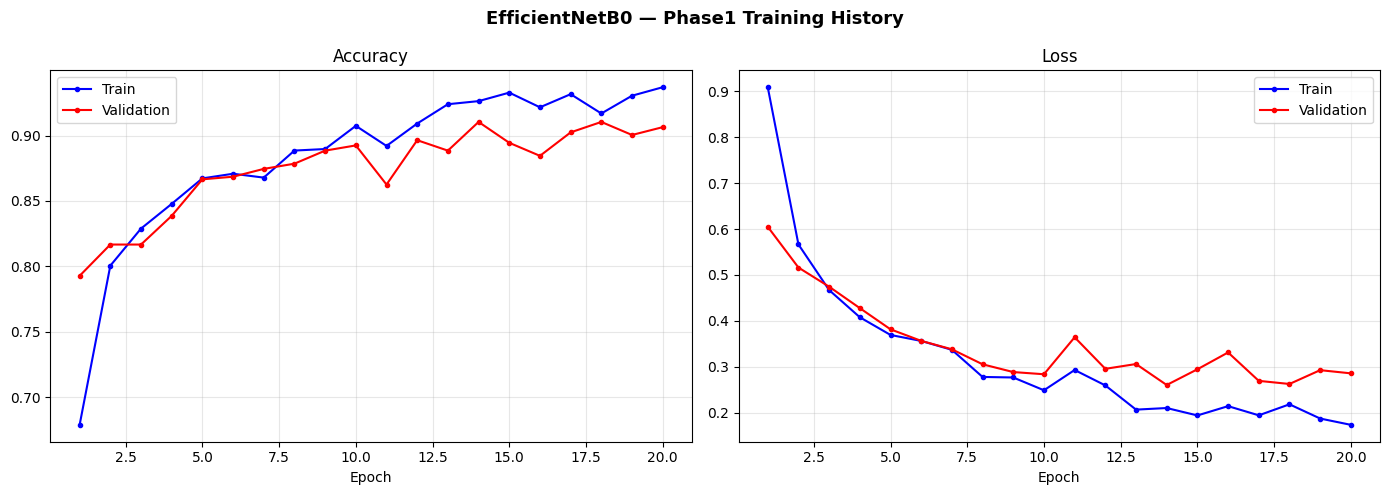


 Phase 2 — Fine-tuning top 30 layers...
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.8674 - loss: 0.4002
Epoch 1: val_accuracy improved from None to 0.88247, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8702 - loss: 0.3599 - val_accuracy: 0.8825 - val_loss: 0.3334 - learning_rate: 1.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8873 - loss: 0.3156
Epoch 2: val_accuracy improved from 0.88247 to 0.88845, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 649ms/step - accuracy: 0.8914 - loss: 0.2948 - val_accuracy: 0.8884 - val_loss: 0.3411 - learning_rate: 1.0000e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9100 - loss: 0.2454
Epoch 3: val_accuracy improved from 0.88845 to 0.89841, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 3: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 920ms/step - accuracy: 0.9068 - loss: 0.2413 - val_accuracy: 0.8984 - val_loss: 0.3188 - learning_rate: 1.0000e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.9279 - loss: 0.2085
Epoch 4: val_accuracy improved from 0.89841 to 0.90040, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 805ms/step - accuracy: 0.9310 - loss: 0.2005 - val_accuracy: 0.9004 - val_loss: 0.3140 - learning_rate: 1.0000e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9389 - loss: 0.1698
Epoch 5: val_accuracy improved from 0.90040 to 0.90837, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 5: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 654ms/step - accuracy: 0.9392 - loss: 0.1740 - val_accuracy: 0.9084 - val_loss: 0.3029 - learning_rate: 1.0000e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9405 - loss: 0.1778
Epoch 6: val_accuracy did not improve from 0.90837
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 628ms/step - accuracy: 0.9428 - loss: 0.1650 - val_accuracy: 0.9024 - val_loss: 0.2983 - learning_rate: 1.0000e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9274 - loss: 0.1819
Epoch 7: val_accuracy improved from 0.90837 to 0.91434, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 7: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 637ms/step - accuracy: 0.9363 - loss: 0.1638 - val_accuracy: 0.9143 - val_loss: 0.2751 - learning_rate: 1.0000e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9443 - loss: 0.1486
Epoch 8: val_accuracy did not improve from 0.91434
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 617ms/step - accuracy: 0.9422 - loss: 0.1594 - val_accuracy: 0.9104 - val_loss: 0.2886 - learning_rate: 1.0000e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9587 - loss: 0.1162
Epoch 9: val_accuracy improved from 0.91434 to 0.91833, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 9: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 673ms/step - accuracy: 0.9605 - loss: 0.1202 - val_accuracy: 0.9183 - val_loss: 0.2858 - learning_rate: 1.0000e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9530 - loss: 0.1262
Epoch 10: val_accuracy did not improve from 0.91833
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 606ms/step - accuracy: 0.9534 - loss: 0.1250 - val_accuracy: 0.9183 - val_loss: 0.2905 - learning_rate: 1.0000e-04
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9550 - loss: 0.1199
Epoch 11: val_accuracy improved from 0.91833 to 0.92032, saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5



Epoch 11: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 631ms/step - accuracy: 0.9569 - loss: 0.1335 - val_accuracy: 0.9203 - val_loss: 0.2998 - learning_rate: 1.0000e-04
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.9717 - loss: 0.0948
Epoch 12: val_accuracy did not improve from 0.92032
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 694ms/step - accuracy: 0.9717 - loss: 0.0953 - val_accuracy: 0.9183 - val_loss: 0.3036 - learning_rate: 5.0000e-05
Epoch 13/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9675 - loss: 0.0855
Epoch 13: val_accuracy did not improve from 0.92032
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 593ms/step - accuracy: 0.9640 - loss: 0.0945 - val_accuracy: 0.9183 - val_loss: 0.3053 - learning_rate: 5.0000e-05
Epoch 14/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9666 - loss: 0.0937
Epoch 14: val_accuracy i


Epoch 14: finished saving model to /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 693ms/step - accuracy: 0.9729 - loss: 0.0793 - val_accuracy: 0.9323 - val_loss: 0.2906 - learning_rate: 5.0000e-05
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 7.


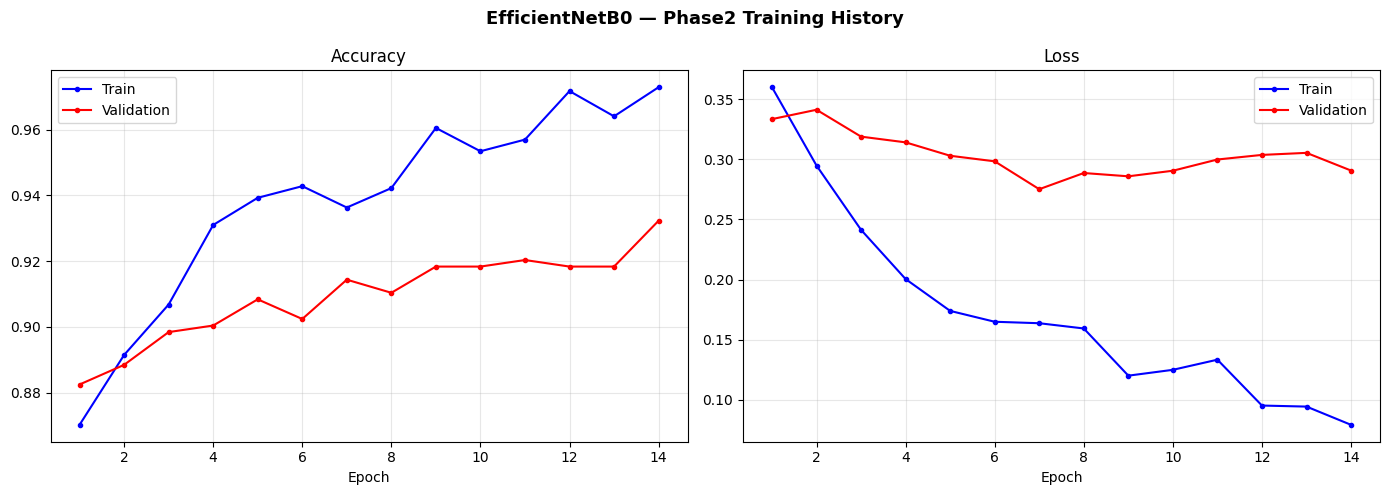


  EfficientNetB0 — TEST RESULTS
  Accuracy  : 92.28%
  Precision : 0.9232
  Recall    : 0.9228
  F1 Score  : 0.9222
  Loss      : 0.4082

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.95      0.94        80
  meningioma       0.87      0.87      0.87        63
    no_tumor       0.95      0.86      0.90        49
   pituitary       0.93      1.00      0.96        54

    accuracy                           0.92       246
   macro avg       0.92      0.92      0.92       246
weighted avg       0.92      0.92      0.92       246



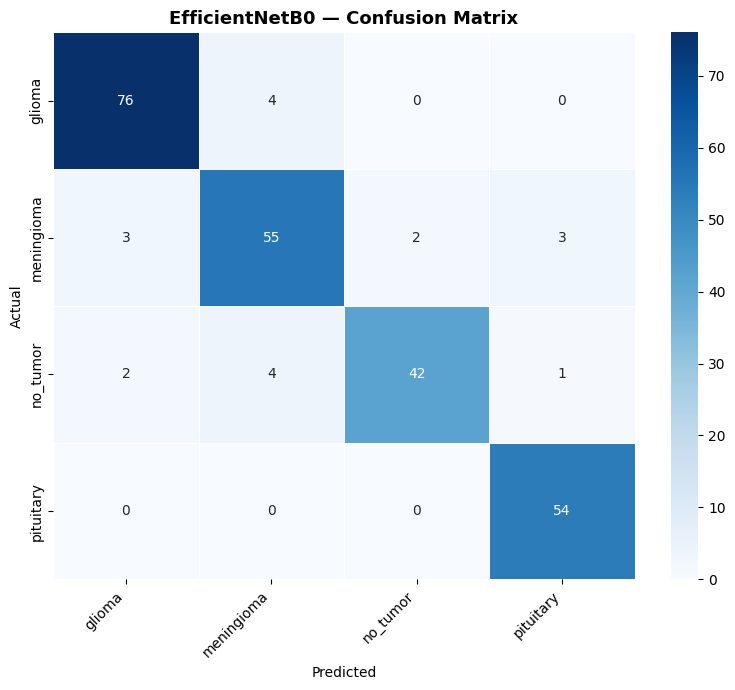

 EfficientNetB0 saved → /content/drive/MyDrive/BrainTumor/models/efficientnetb0.h5


In [7]:
#  EfficientNetB0

print("=" * 50)
print("  MODEL 1 — EfficientNetB0")
print("=" * 50)

base_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
eff_model = build_transfer_model(base_eff)
eff_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f" Built | Params: {eff_model.count_params():,}")

# Phase 1
print("\n Phase 1 — Frozen base training...")
cb_eff, path_eff = get_callbacks("efficientnetb0")
h_eff_p1 = eff_model.fit(
    train_gen_eff, epochs=EPOCHS_P1,
    validation_data=valid_gen_eff,
    callbacks=cb_eff, verbose=1
)
plot_history(h_eff_p1, "EfficientNetB0", "Phase1")

# Phase 2
print("\n Phase 2 — Fine-tuning top 30 layers...")
base_eff.trainable = True
for layer in base_eff.layers[:-30]:
    layer.trainable = False
eff_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cb_eff2, _ = get_callbacks("efficientnetb0")
h_eff_p2 = eff_model.fit(
    train_gen_eff, epochs=EPOCHS_P2,
    validation_data=valid_gen_eff,
    callbacks=cb_eff2, verbose=1
)
plot_history(h_eff_p2, "EfficientNetB0", "Phase2")

# Evaluate
acc_eff, prec_eff, rec_eff, f1_eff, loss_eff, pred_eff, true_eff = \
    evaluate_model(eff_model, test_gen_eff, "EfficientNetB0")
plot_confusion_matrix(true_eff, pred_eff, "EfficientNetB0")
print(f" EfficientNetB0 saved → {path_eff}")

  MODEL 2 — MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Built | Params: 2,624,452

 Phase 1 — Frozen base training...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.5786 - loss: 1.2040
Epoch 1: val_accuracy improved from None to 0.76693, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6938 - loss: 0.9197 - val_accuracy: 0.7669 - val_loss: 0.6181 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7881 - loss: 0.5879
Epoch 2: val_accuracy improved from 0.76693 to 0.82271, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 685ms/step - accuracy: 0.7971 - loss: 0.5681 - val_accuracy: 0.8227 - val_loss: 0.5021 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.8630 - loss: 0.3981
Epoch 3: val_accuracy improved from 0.82271 to 0.83466, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 677ms/step - accuracy: 0.8496 - loss: 0.4131 - val_accuracy: 0.8347 - val_loss: 0.5093 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8637 - loss: 0.3931
Epoch 4: val_accuracy improved from 0.83466 to 0.86653, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 663ms/step - accuracy: 0.8507 - loss: 0.4213 - val_accuracy: 0.8665 - val_loss: 0.4146 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.8658 - loss: 0.4012
Epoch 5: val_accuracy did not improve from 0.86653
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 651ms/step - accuracy: 0.8678 - loss: 0.3503 - val_accuracy: 0.8446 - val_loss: 0.4153 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8799 - loss: 0.3255
Epoch 6: val_accuracy did not improve from 0.86653
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 648ms/step - accuracy: 0.8838 - loss: 0.3280 - val_accuracy: 0.8426 - val_loss: 0.4633 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.8756 - loss: 0.3335
Epoch 7: val_accuracy improved from 0.86653 to 0.87052, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv

...


Epoch 12: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 693ms/step - accuracy: 0.9286 - loss: 0.2069 - val_accuracy: 0.8845 - val_loss: 0.3759 - learning_rate: 5.0000e-04
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9339 - loss: 0.1700
Epoch 13: val_accuracy improved from 0.88446 to 0.88845, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 13: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 672ms/step - accuracy: 0.9227 - loss: 0.1910 - val_accuracy: 0.8884 - val_loss: 0.3727 - learning_rate: 5.0000e-04
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9365 - loss: 0.1900
Epoch 14: val_accuracy did not improve from 0.88845
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 691ms/step - accuracy: 0.9351 - loss: 0.1972 - val_accuracy: 0.8845 - val_loss: 0.3747 - learning_rate: 5.0000e-04
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9139 - loss: 0.2107
Epoch 15: val_accuracy did not improve from 0.88845
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 644ms/step - accuracy: 0.9204 - loss: 0.1972 - val_accuracy: 0.8805 - val_loss: 0.3788 - learning_rate: 5.0000e-04
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9370 - loss: 0.1797
Epoch 16: val_accuracy did not improve from 0.88845
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 687ms/step - accuracy:


Epoch 17: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 689ms/step - accuracy: 0.9345 - loss: 0.1785 - val_accuracy: 0.8904 - val_loss: 0.3578 - learning_rate: 5.0000e-04
Epoch 18/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9408 - loss: 0.1696
Epoch 18: val_accuracy improved from 0.89044 to 0.89243, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 18: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 710ms/step - accuracy: 0.9410 - loss: 0.1583 - val_accuracy: 0.8924 - val_loss: 0.3364 - learning_rate: 5.0000e-04
Epoch 19/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.9384 - loss: 0.1566
Epoch 19: val_accuracy improved from 0.89243 to 0.89641, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 19: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 678ms/step - accuracy: 0.9375 - loss: 0.1575 - val_accuracy: 0.8964 - val_loss: 0.3498 - learning_rate: 5.0000e-04
Epoch 20/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9432 - loss: 0.1672
Epoch 20: val_accuracy did not improve from 0.89641
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 666ms/step - accuracy: 0.9445 - loss: 0.1595 - val_accuracy: 0.8924 - val_loss: 0.3478 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.


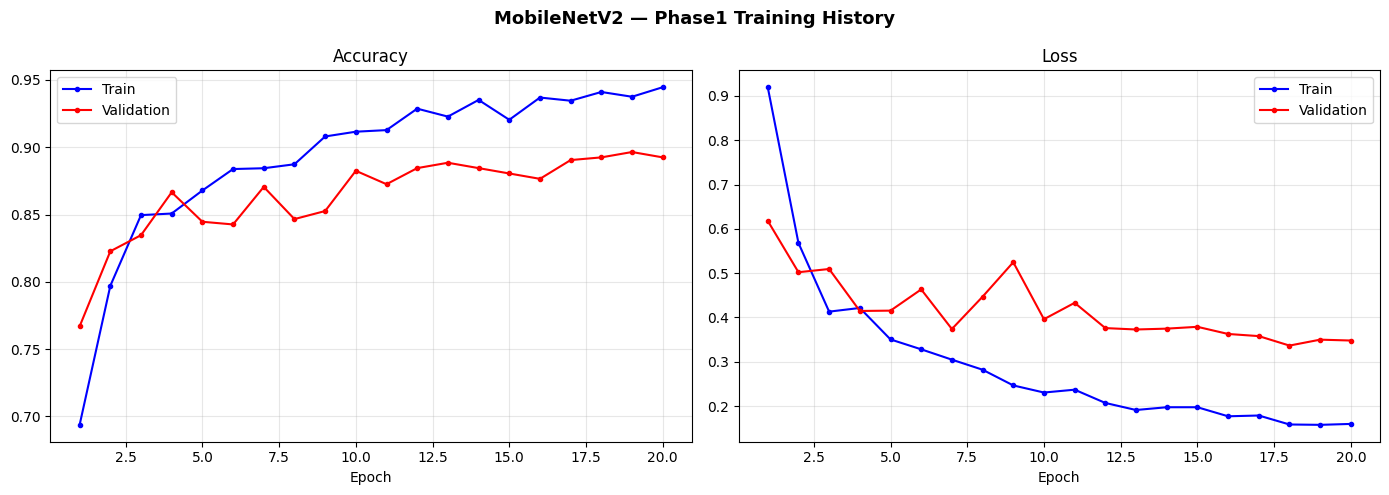


 Phase 2 — Fine-tuning top 30 layers...
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.8498 - loss: 0.4394
Epoch 1: val_accuracy improved from None to 0.77291, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8761 - loss: 0.3624 - val_accuracy: 0.7729 - val_loss: 1.1120 - learning_rate: 1.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9054 - loss: 0.2336
Epoch 2: val_accuracy improved from 0.77291 to 0.77490, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 699ms/step - accuracy: 0.9086 - loss: 0.2316 - val_accuracy: 0.7749 - val_loss: 1.1197 - learning_rate: 1.0000e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9307 - loss: 0.1930
Epoch 3: val_accuracy did not improve from 0.77490
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 658ms/step - accuracy: 0.9274 - loss: 0.2014 - val_accuracy: 0.7490 - val_loss: 1.3128 - learning_rate: 1.0000e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9302 - loss: 0.1719
Epoch 4: val_accuracy did not improve from 0.77490
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 650ms/step - accuracy: 0.9410 - loss: 0.1503 - val_accuracy: 0.7131 - val_loss: 1.7624 - learning_rate: 1.0000e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9602 - loss: 0.1134
Epoch 5: val_accuracy did not improve from 0.77490

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.9999


Epoch 7: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 701ms/step - accuracy: 0.9687 - loss: 0.0987 - val_accuracy: 0.8307 - val_loss: 0.7423 - learning_rate: 5.0000e-05
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9745 - loss: 0.0792
Epoch 8: val_accuracy improved from 0.83068 to 0.84861, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 691ms/step - accuracy: 0.9705 - loss: 0.0942 - val_accuracy: 0.8486 - val_loss: 0.5694 - learning_rate: 5.0000e-05
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9746 - loss: 0.0816
Epoch 9: val_accuracy improved from 0.84861 to 0.85259, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5


...


Epoch 20: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 684ms/step - accuracy: 0.9864 - loss: 0.0412 - val_accuracy: 0.9203 - val_loss: 0.3023 - learning_rate: 2.5000e-05
Epoch 21/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.9898 - loss: 0.0371
Epoch 21: val_accuracy improved from 0.92032 to 0.92829, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 21: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 693ms/step - accuracy: 0.9835 - loss: 0.0476 - val_accuracy: 0.9283 - val_loss: 0.2828 - learning_rate: 2.5000e-05
Epoch 22/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9904 - loss: 0.0390
Epoch 22: val_accuracy did not improve from 0.92829
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 647ms/step - accuracy: 0.9888 - loss: 0.0383 - val_accuracy: 0.9223 - val_loss: 0.2862 - learning_rate: 2.5000e-05
Epoch 23/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9871 - loss: 0.0397
Epoch 23: val_accuracy improved from 0.92829 to 0.93028, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 23: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 678ms/step - accuracy: 0.9894 - loss: 0.0325 - val_accuracy: 0.9303 - val_loss: 0.2699 - learning_rate: 2.5000e-05
Epoch 24/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9908 - loss: 0.0261
Epoch 24: val_accuracy did not improve from 0.93028
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 650ms/step - accuracy: 0.9870 - loss: 0.0329 - val_accuracy: 0.9263 - val_loss: 0.2890 - learning_rate: 2.5000e-05
Epoch 25/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9896 - loss: 0.0298
Epoch 25: val_accuracy improved from 0.93028 to 0.93227, saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5



Epoch 25: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 670ms/step - accuracy: 0.9888 - loss: 0.0334 - val_accuracy: 0.9323 - val_loss: 0.2764 - learning_rate: 2.5000e-05
Epoch 26/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.9918 - loss: 0.0347
Epoch 26: val_accuracy did not improve from 0.93227
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 694ms/step - accuracy: 0.9923 - loss: 0.0323 - val_accuracy: 0.9303 - val_loss: 0.2829 - learning_rate: 2.5000e-05
Epoch 27/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9846 - loss: 0.0529
Epoch 27: val_accuracy did not improve from 0.93227

Epoch 27: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 638ms/step - accuracy: 0.9888 - loss: 0.0381 - val_accuracy: 0.9283 - val_loss: 0.2845 - learning_rate: 2.5000e-05
Epoch 28/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9824 - loss: 0.0605
Epoch 28: val_accuracy did 


Epoch 29: finished saving model to /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 699ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9363 - val_loss: 0.2743 - learning_rate: 1.2500e-05
Epoch 30/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9874 - loss: 0.0359
Epoch 30: val_accuracy did not improve from 0.93625
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 658ms/step - accuracy: 0.9888 - loss: 0.0386 - val_accuracy: 0.9283 - val_loss: 0.2842 - learning_rate: 1.2500e-05
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 23.


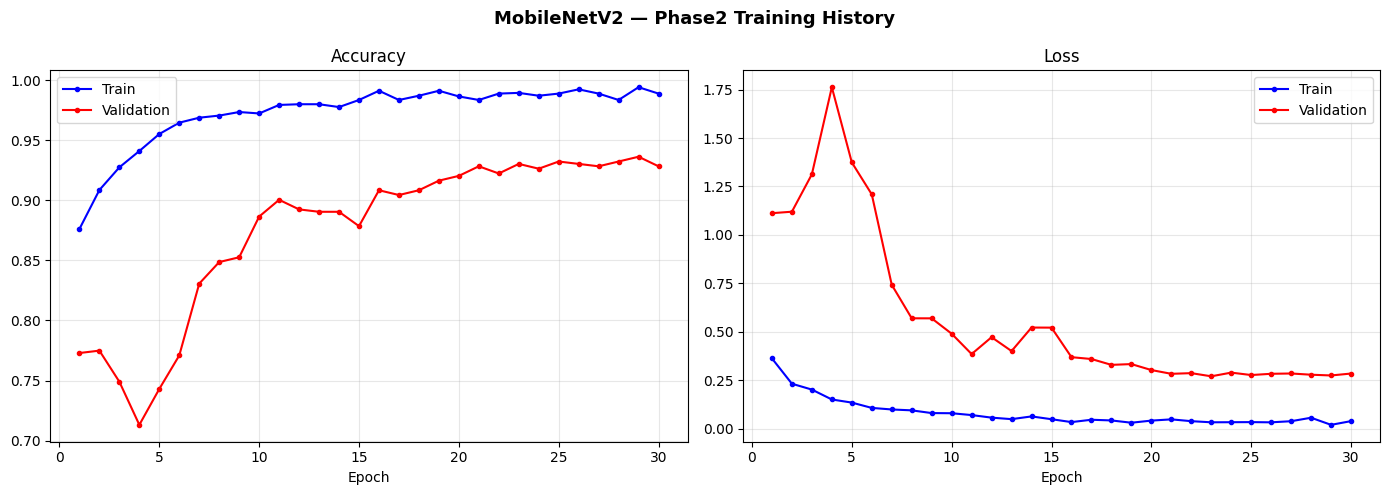


  MobileNetV2 — TEST RESULTS
  Accuracy  : 91.87%
  Precision : 0.9188
  Recall    : 0.9187
  F1 Score  : 0.9171
  Loss      : 0.4255

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.99      0.96        80
  meningioma       0.88      0.83      0.85        63
    no_tumor       0.95      0.84      0.89        49
   pituitary       0.92      1.00      0.96        54

    accuracy                           0.92       246
   macro avg       0.92      0.91      0.91       246
weighted avg       0.92      0.92      0.92       246



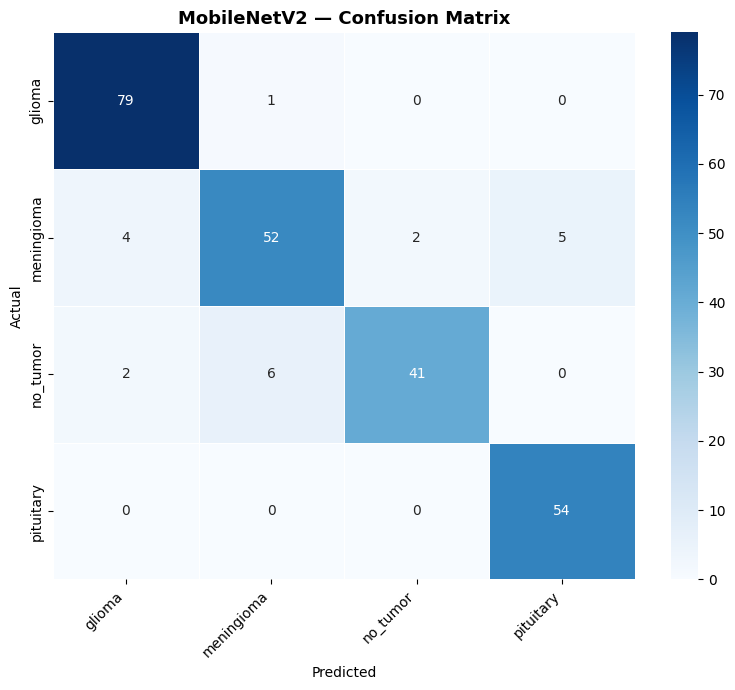

 MobileNetV2 saved → /content/drive/MyDrive/BrainTumor/models/mobilenetv2.h5


In [8]:
# MobileNetV2

print("=" * 50)
print("  MODEL 2 — MobileNetV2")
print("=" * 50)

base_mob = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
mob_model = build_transfer_model(base_mob)
mob_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f" Built | Params: {mob_model.count_params():,}")

# Phase 1
print("\n Phase 1 — Frozen base training...")
cb_mob, path_mob = get_callbacks("mobilenetv2")
h_mob_p1 = mob_model.fit(
    train_generator, epochs=EPOCHS_P1,
    validation_data=valid_generator,
    callbacks=cb_mob, verbose=1
)
plot_history(h_mob_p1, "MobileNetV2", "Phase1")

# Phase 2
print("\n Phase 2 — Fine-tuning top 30 layers...")
base_mob.trainable = True
for layer in base_mob.layers[:-30]:
    layer.trainable = False
mob_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cb_mob2, _ = get_callbacks("mobilenetv2")
h_mob_p2 = mob_model.fit(
    train_generator, epochs=EPOCHS_P2,
    validation_data=valid_generator,
    callbacks=cb_mob2, verbose=1
)
plot_history(h_mob_p2, "MobileNetV2", "Phase2")

# Evaluate
acc_mob, prec_mob, rec_mob, f1_mob, loss_mob, pred_mob, true_mob = \
    evaluate_model(mob_model, test_generator, "MobileNetV2")
plot_confusion_matrix(true_mob, pred_mob, "MobileNetV2")
print(f" MobileNetV2 saved → {path_mob}")


  MODEL 3 — ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Built | Params: 24,153,860

 Phase 1 — Frozen base training...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.4958 - loss: 1.1945
Epoch 1: val_accuracy improved from None to 0.24502, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5540 - loss: 1.1032 - val_accuracy: 0.2450 - val_loss: 1.3308 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.6101 - loss: 1.0063
Epoch 2: val_accuracy improved from 0.24502 to 0.36853, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 779ms/step - accuracy: 0.6059 - loss: 1.0094 - val_accuracy: 0.3685 - val_loss: 1.2606 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6574 - loss: 0.8947
Epoch 3: val_accuracy improved from 0.36853 to 0.40637, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 3: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 782ms/step - accuracy: 0.6442 - loss: 0.9124 - val_accuracy: 0.4064 - val_loss: 1.1881 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.6491 - loss: 0.9155
Epoch 4: val_accuracy improved from 0.40637 to 0.47012, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 757ms/step - accuracy: 0.6425 - loss: 0.9098 - val_accuracy: 0.4701 - val_loss: 1.1602 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6570 - loss: 0.8523
Epoch 5: val_accuracy improved from 0.47012 to 0.66932, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 714ms/step - accuracy: 0.6690 - loss: 0.8688 - val_accuracy: 0.6972 - val_loss: 1.0167 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.6763 - loss: 0.8258
Epoch 7: val_accuracy improved from 0.69721 to 0.74303, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 7: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 751ms/step - accuracy: 0.6909 - loss: 0.8001 - val_accuracy: 0.7430 - val_loss: 0.8534 - learning_rate: 0.0010
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.6783 - loss: 0.7916
Epoch 8: val_accuracy did not improve from 0.74303
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 717ms/step - accuracy: 0.6861 - loss: 0.7934 - val_accuracy: 0.7171 - val_loss: 0.7944 - learning_rate: 0.0010
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6745 - loss: 0.8295
Epoch 9: val_accuracy did not improve from 0.74303
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 666ms/step - accuracy: 0.6743 - loss: 0.8156 - val_accuracy: 0.7191 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.6939 - loss: 0.7685
Epoch 10: val_accuracy did not improve from 0.74303
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 684ms/step - accuracy: 0.6979 - loss: 0.76


Epoch 11: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 707ms/step - accuracy: 0.6749 - loss: 0.8250 - val_accuracy: 0.7510 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.7127 - loss: 0.7378
Epoch 12: val_accuracy did not improve from 0.75100
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 722ms/step - accuracy: 0.7074 - loss: 0.7382 - val_accuracy: 0.7470 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.7013 - loss: 0.7498
Epoch 13: val_accuracy did not improve from 0.75100
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 664ms/step - accuracy: 0.6808 - loss: 0.7781 - val_accuracy: 0.7331 - val_loss: 0.6394 - learning_rate: 0.0010
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6904 - loss: 0.7571
Epoch 14: val_accuracy improved from 0.75100 to 0.75697, saving model to /content/drive/MyDrive/BrainTumor/models/resnet


Epoch 14: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 720ms/step - accuracy: 0.7056 - loss: 0.7361 - val_accuracy: 0.7570 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.6872 - loss: 0.7580
Epoch 15: val_accuracy did not improve from 0.75697
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 665ms/step - accuracy: 0.7015 - loss: 0.7549 - val_accuracy: 0.7331 - val_loss: 0.6437 - learning_rate: 0.0010
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.6888 - loss: 0.7594
Epoch 16: val_accuracy did not improve from 0.75697
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 656ms/step - accuracy: 0.7062 - loss: 0.7228 - val_accuracy: 0.7550 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.7138 - loss: 0.6971
Epoch 17: val_accuracy did not improve from 0.75697
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 639ms/step - accuracy: 0.7150 - loss:


Epoch 20: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 720ms/step - accuracy: 0.7298 - loss: 0.6733 - val_accuracy: 0.7729 - val_loss: 0.5756 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 20.


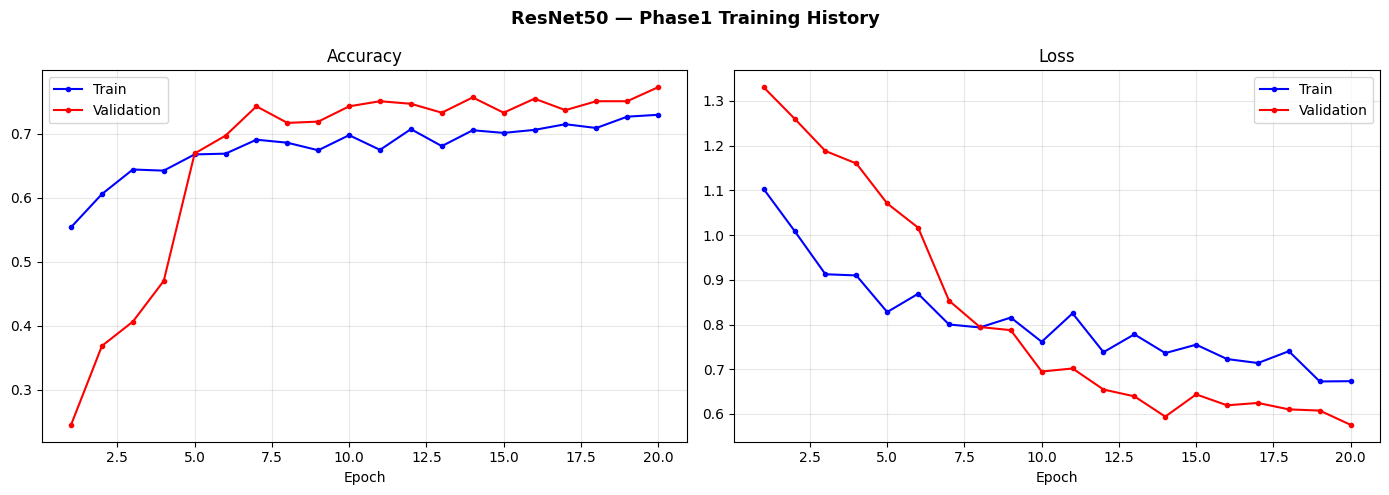


 Phase 2 — Fine-tuning top 30 layers...
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.5453 - loss: 1.4859
Epoch 1: val_accuracy improved from None to 0.37649, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5823 - loss: 1.2650 - val_accuracy: 0.3765 - val_loss: 6.4837 - learning_rate: 1.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.5949 - loss: 1.0677
Epoch 2: val_accuracy improved from 0.37649 to 0.46813, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 985ms/step - accuracy: 0.6313 - loss: 0.9566 - val_accuracy: 0.4681 - val_loss: 3.4682 - learning_rate: 1.0000e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.6877 - loss: 0.8707
Epoch 3: val_accuracy improved from 0.46813 to 0.50000, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 3: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 77s 896ms/step - accuracy: 0.6667 - loss: 0.8998 - val_accuracy: 0.5000 - val_loss: 2.2056 - learning_rate: 1.0000e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.6798 - loss: 0.8392
Epoch 4: val_accuracy improved from 0.50000 to 0.67131, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 845ms/step - accuracy: 0.6867 - loss: 0.8365 - val_accuracy: 0.6713 - val_loss: 1.2302 - learning_rate: 1.0000e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.7017 - loss: 0.8250
Epoch 5: val_accuracy improved from 0.67131 to 0.68127, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5


...


Epoch 15: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 851ms/step - accuracy: 0.7440 - loss: 0.6475 - val_accuracy: 0.7769 - val_loss: 0.5858 - learning_rate: 5.0000e-05
Epoch 16/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.7660 - loss: 0.5911
Epoch 16: val_accuracy did not improve from 0.77689
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 772ms/step - accuracy: 0.7652 - loss: 0.6094 - val_accuracy: 0.7231 - val_loss: 0.7018 - learning_rate: 5.0000e-05
Epoch 17/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7552 - loss: 0.6438
Epoch 17: val_accuracy did not improve from 0.77689
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 694ms/step - accuracy: 0.7587 - loss: 0.6397 - val_accuracy: 0.6016 - val_loss: 0.9719 - learning_rate: 5.0000e-05
Epoch 18/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.7588 - loss: 0.6447
Epoch 18: val_accuracy did not improve from 0.77689
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 670ms/step - accuracy: 0.


Epoch 21: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 793ms/step - accuracy: 0.7628 - loss: 0.5924 - val_accuracy: 0.7869 - val_loss: 0.5335 - learning_rate: 2.5000e-05
Epoch 22/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.7828 - loss: 0.5578
Epoch 22: val_accuracy improved from 0.78685 to 0.78884, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 22: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 942ms/step - accuracy: 0.7894 - loss: 0.5496 - val_accuracy: 0.7888 - val_loss: 0.5364 - learning_rate: 2.5000e-05
Epoch 23/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.7950 - loss: 0.5480
Epoch 23: val_accuracy did not improve from 0.78884
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 775ms/step - accuracy: 0.7823 - loss: 0.5706 - val_accuracy: 0.7610 - val_loss: 0.6525 - learning_rate: 2.5000e-05
Epoch 24/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.7738 - loss: 0.5724
Epoch 24: val_accuracy did not improve from 0.78884
53/53 ━━━━━━━━━━━━━━━━━━━━ 76s 665ms/step - accuracy: 0.7823 - loss: 0.5474 - val_accuracy: 0.7331 - val_loss: 0.6634 - learning_rate: 2.5000e-05
Epoch 25/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.7745 - loss: 0.5503
Epoch 25: val_accuracy did not improve from 0.78884

Epoch 25: ReduceLROnPlateau reducing learning rate to 1


Epoch 27: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 910ms/step - accuracy: 0.8065 - loss: 0.5094 - val_accuracy: 0.7948 - val_loss: 0.5380 - learning_rate: 1.2500e-05
Epoch 28/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.7973 - loss: 0.5132
Epoch 28: val_accuracy improved from 0.79482 to 0.82470, saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5



Epoch 28: finished saving model to /content/drive/MyDrive/BrainTumor/models/resnet50.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7976 - loss: 0.5252 - val_accuracy: 0.8247 - val_loss: 0.4641 - learning_rate: 1.2500e-05
Epoch 29/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.7750 - loss: 0.5707
Epoch 29: val_accuracy did not improve from 0.82470
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 852ms/step - accuracy: 0.7841 - loss: 0.5528 - val_accuracy: 0.7649 - val_loss: 0.5768 - learning_rate: 1.2500e-05
Epoch 30/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.7951 - loss: 0.5207
Epoch 30: val_accuracy did not improve from 0.82470
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 660ms/step - accuracy: 0.7894 - loss: 0.5288 - val_accuracy: 0.8048 - val_loss: 0.5134 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 28.


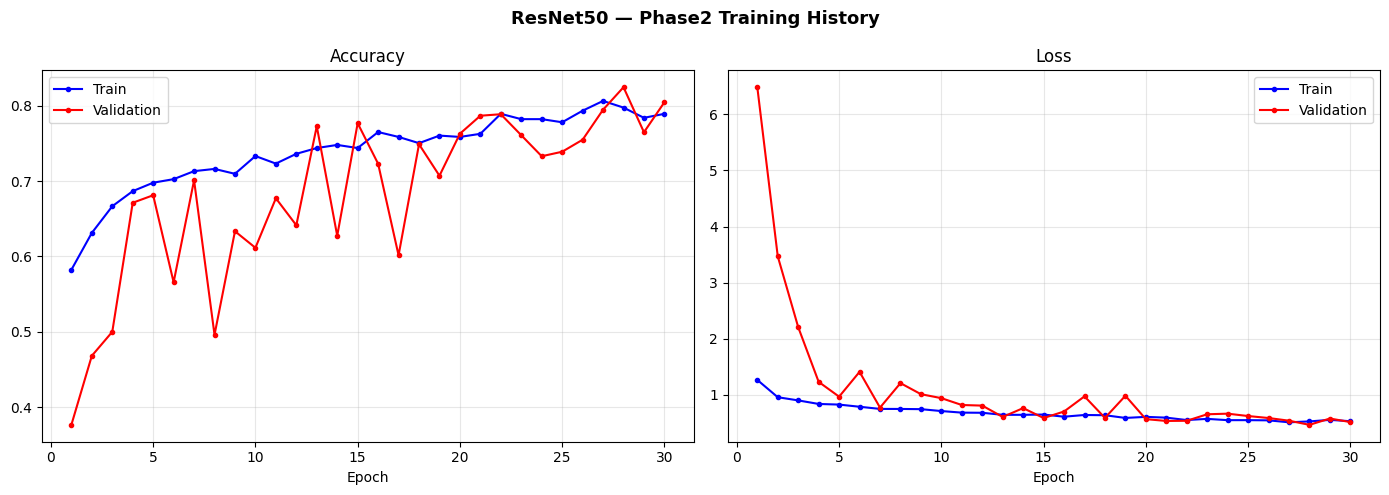


  ResNet50 — TEST RESULTS
  Accuracy  : 80.08%
  Precision : 0.7952
  Recall    : 0.8008
  F1 Score  : 0.7821
  Loss      : 0.4477

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.82      0.90      0.86        80
  meningioma       0.74      0.41      0.53        63
    no_tumor       0.75      0.96      0.84        49
   pituitary       0.87      0.96      0.91        54

    accuracy                           0.80       246
   macro avg       0.79      0.81      0.78       246
weighted avg       0.80      0.80      0.78       246



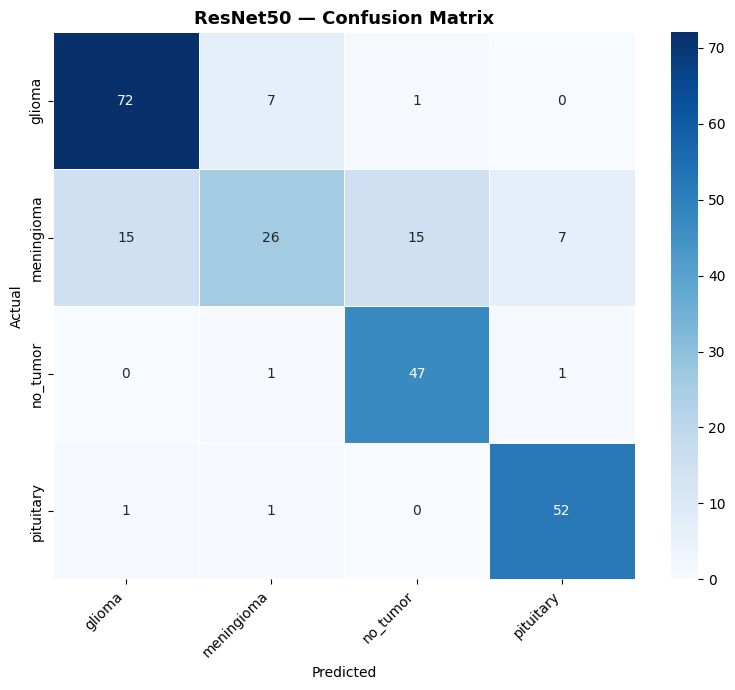

 ResNet50 saved → /content/drive/MyDrive/BrainTumor/models/resnet50.h5


In [9]:
#  ResNet50

print("=" * 50)
print("  MODEL 3 — ResNet50")
print("=" * 50)

base_res = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
res_model = build_transfer_model(base_res)
res_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f" Built | Params: {res_model.count_params():,}")

# Phase 1
print("\n Phase 1 — Frozen base training...")
cb_res, path_res = get_callbacks("resnet50")
h_res_p1 = res_model.fit(
    train_generator, epochs=EPOCHS_P1,
    validation_data=valid_generator,
    callbacks=cb_res, verbose=1
)
plot_history(h_res_p1, "ResNet50", "Phase1")

# Phase 2
print("\n Phase 2 — Fine-tuning top 30 layers...")
base_res.trainable = True
for layer in base_res.layers[:-30]:
    layer.trainable = False
res_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cb_res2, _ = get_callbacks("resnet50")
h_res_p2 = res_model.fit(
    train_generator, epochs=EPOCHS_P2,
    validation_data=valid_generator,
    callbacks=cb_res2, verbose=1
)
plot_history(h_res_p2, "ResNet50", "Phase2")

# Evaluate
acc_res, prec_res, rec_res, f1_res, loss_res, pred_res, true_res = \
    evaluate_model(res_model, test_generator, "ResNet50")
plot_confusion_matrix(true_res, pred_res, "ResNet50")
print(f" ResNet50 saved → {path_res}")

In [10]:
#  Save All Results

all_results = pd.DataFrame([
    {
        'Model'    : 'Custom CNN',
        'Accuracy' : 65.04,
        'Precision': 0.6857,
        'Recall'   : 0.6504,
        'F1_Score' : 0.6410,
        'Loss'     : 0.7577
    },
    {
        'Model'    : 'EfficientNetB0',
        'Accuracy' : round(acc_eff * 100, 2),
        'Precision': round(prec_eff, 4),
        'Recall'   : round(rec_eff, 4),
        'F1_Score' : round(f1_eff, 4),
        'Loss'     : round(loss_eff, 4)
    },
    {
        'Model'    : 'MobileNetV2',
        'Accuracy' : round(acc_mob * 100, 2),
        'Precision': round(prec_mob, 4),
        'Recall'   : round(rec_mob, 4),
        'F1_Score' : round(f1_mob, 4),
        'Loss'     : round(loss_mob, 4)
    },
    {
        'Model'    : 'ResNet50',
        'Accuracy' : round(acc_res * 100, 2),
        'Precision': round(prec_res, 4),
        'Recall'   : round(rec_res, 4),
        'F1_Score' : round(f1_res, 4),
        'Loss'     : round(loss_res, 4)
    }
])

results_path = os.path.join(MODELS_DIR, "model_results.csv")
all_results.to_csv(results_path, index=False)

print("=" * 55)
print("      ALL MODELS — FINAL COMPARISON")
print("=" * 55)
print(all_results.to_string(index=False))
print("=" * 55)
print(f"\n Results saved → {results_path}")
print("\n  Next Step → Notebook 5: Model Evaluation & Comparison")


      ALL MODELS — FINAL COMPARISON
         Model  Accuracy  Precision  Recall  F1_Score   Loss
    Custom CNN     65.04     0.6857  0.6504    0.6410 0.7577
EfficientNetB0     92.28     0.9232  0.9228    0.9222 0.4082
   MobileNetV2     91.87     0.9188  0.9187    0.9171 0.4255
      ResNet50     80.08     0.7952  0.8008    0.7821 0.4477

 Results saved → /content/drive/MyDrive/BrainTumor/models/model_results.csv

  Next Step → Notebook 5: Model Evaluation & Comparison
